<a href="https://colab.research.google.com/github/aayushka1/Data-Science-Learning/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

## Overview

Logistic Regression is a supervised machine learning algorithm used for classification tasks, where the objective is to predict discrete class labels based on input features. Unlike Linear Regression, which predicts continuous values, Logistic Regression estimates the probability of an observation belonging to a particular class using the sigmoid function.

This notebook introduces the fundamental concepts of classification, discusses the limitations of applying Linear Regression to classification problems, and explains the mathematical foundation of Logistic Regression, including the sigmoid function and the concept of the decision boundary.

---

## Topics Covered

- Introduction to Classification
- Limitations of Linear Regression for Classification
- Logistic Regression
- Sigmoid (Logistic) Function
- Decision Boundary

---

## Objective

The objective of this notebook is to understand the theoretical foundation of Logistic Regression and develop an intuition for how it models probabilities and separates classes using the sigmoid function and a decision boundary.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Synthetic Dataset

A synthetic dataset is generated to demonstrate the fundamentals of binary classification using Logistic Regression. The dataset consists of students' GRE scores and their corresponding admission status.

In [43]:
from sklearn.datasets import make_classification

def generate_dataset():
  dataset = make_classification(n_samples=20, n_features=1, n_repeated=0, n_redundant=0,  shift=30,
                                scale=10, n_classes=2, n_clusters_per_class=1, n_informative=1,
                                class_sep=1, random_state=1)
  df = pd.DataFrame(dataset[0])
  df = pd.concat([(np.ceil(df)).astype(int), pd.DataFrame(dataset[1])], axis=1)
  df.columns = ['GRE_Score', 'Admission']
  return df

In [44]:
dataset = generate_dataset()
dataset.head()

,GRE_Score,Admission
0,310,1
1,297,0
2,318,1
3,290,0
4,288,0


A scatter plot is used to visualize the distribution of the two classes. The visualization helps determine whether the classes can be separated using a linear decision boundary.

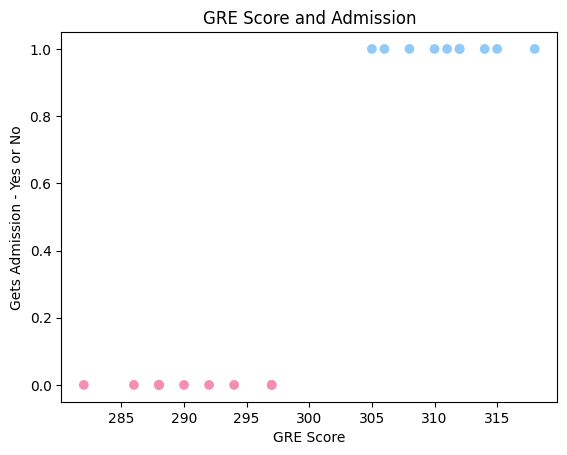

In [45]:
map_color = np.array(['#F48FB1', '#90CAF9'])
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values

plt.scatter(dataset.GRE_Score, dataset.Admission, c = map_color[y])

plt.title('GRE Score and Admission')
plt.xlabel('GRE Score')
plt.ylabel('Gets Admission - Yes or No')
plt.show()

### Linear Regression on Classification Data

A Linear Regression model is fitted to illustrate why it is not suitable for classification problems.

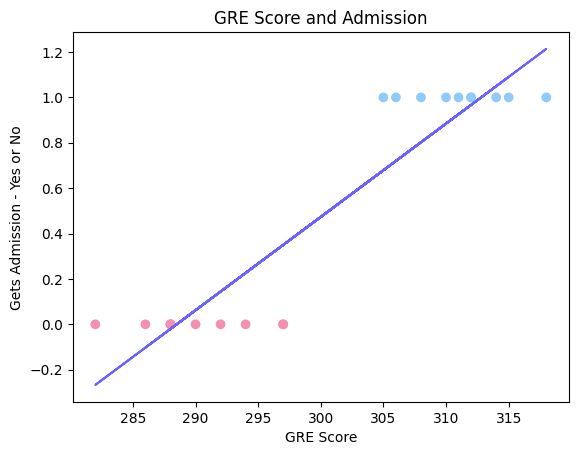

In [46]:
# Import LinearRegression from sklearn.linear_model
from sklearn.linear_model import LinearRegression

linearRegressor = LinearRegression()
linearRegressor.fit(x, y)

plt.scatter(x, y, c=map_color[y])
plt.plot(x, linearRegressor.predict(x), color="#6C63FF")
plt.title('GRE Score and Admission')
plt.xlabel('GRE Score')
plt.ylabel('Gets Admission - Yes or No')

plt.show()

The regression line does not effectively separate the two classes and may produce predictions outside the valid probability range. This highlights the need for a classification algorithm such as Logistic Regression.

### Sigmoid Function

The sigmoid function transforms the linear output into a probability value between 0 and 1, making it suitable for binary classification.

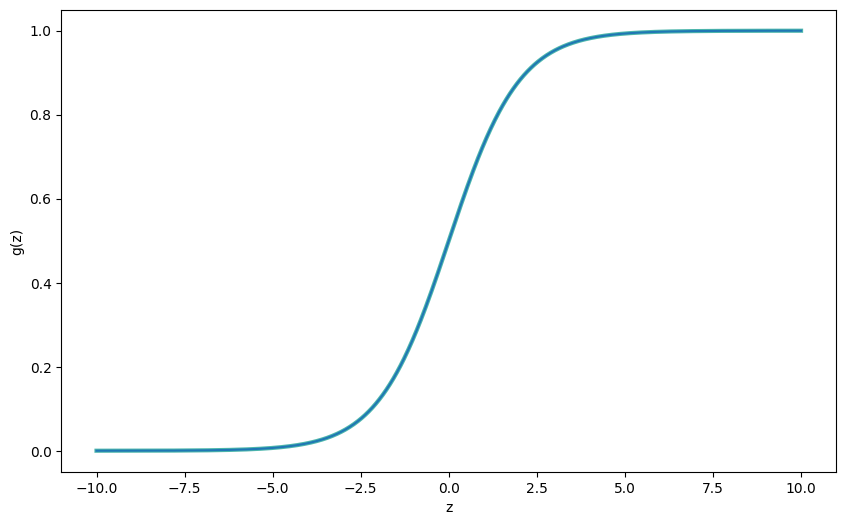

In [47]:
z = np.linspace(-10, 10, 1000) # An array of 1000 elements

# Sigmoid function
def sigma(z):
  return 1/(1 + np.exp(-z))

plt.figure(figsize=(10,6))
plt.plot(z, sigma(z), color="#4DB6AC", linewidth=3)

plt.plot(z, sigma(z))
plt.xlabel("z")
plt.ylabel("g(z)")

plt.show()

The sigmoid curve maps any real-valued input to a probability between 0 and 1. This probability is used to determine the predicted class.

### Logistic Regression Model

A Logistic Regression model is trained using the generated dataset to classify student admission based on GRE scores.

In [48]:
# Import LogisticRegression from sklearn.linear_model
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression()
logistic_regression.fit(x,y)

LogisticRegression()

## Class Prediction

The trained model is used to predict the admission status of new students based on their GRE scores.

In [49]:
class_label_Jacob = logistic_regression.predict([[304]])
print("The predicted class label for Jacob is:", class_label_Jacob)

class_label_Lacy = logistic_regression.predict([[299]])
print("The predicted class label for Lacy is:", class_label_Lacy)

The predicted class label for Jacob is: [1]
The predicted class label for Lacy is: [0]


## Probability Prediction

In addition to class labels, Logistic Regression estimates the probability of an observation belonging to each class using the `predict_proba()` method.

In [50]:
probability_Jacob = logistic_regression.predict_proba([[304]])
print("The probabilities for Jacob are:", probability_Jacob)

probability_Lacy = logistic_regression.predict_proba([[299]])
print("The probabilities for Lacy are:", probability_Lacy)

The probabilities for Jacob are: [[0.10539771 0.89460229]]
The probabilities for Lacy are: [[0.84023034 0.15976966]]


## Decision Boundary

The decision boundary separates the feature space into two regions corresponding to the predicted classes. It is determined by the learned parameters of the Logistic Regression model.

In [51]:
def generate_dataset_2d():
  dataset = make_classification(n_samples=20, n_features=2, n_repeated=0, n_redundant=0,  shift=[31,2.6],
                                scale=[10, 3], n_classes=2, n_clusters_per_class=1, n_informative=2,
                                class_sep=0.9, random_state=10)

  y = pd.DataFrame(dataset[1])
  y = np.where(y > 0.5, 0, 1)
  y = pd.DataFrame(y)
  df = pd.DataFrame(dataset[0])
  df = pd.concat([(df), y], axis=1)
  df.columns = ['GRE_Score', 'CGPA', 'Admission']
  df.GRE_Score = np.ceil(df.GRE_Score).astype(int)
  df.CGPA = np.around(df.CGPA,1)
  return df
  # print(dataset[1],y)

In [52]:
dataset = generate_dataset_2d()
dataset.head()

,GRE_Score,CGPA,Admission
0,313,7.2,1
1,312,7.5,1
2,295,3.3,0
3,325,3.3,1
4,299,4.0,0


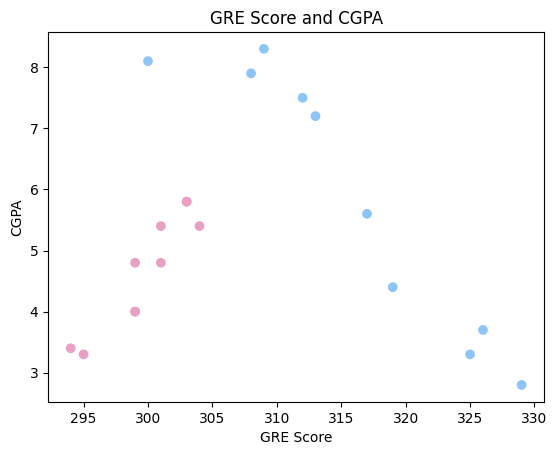

In [55]:
map_color = np.array(['#E8A1C4', '#8EC5F8'])

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 2].values

plt.scatter( dataset.GRE_Score, dataset.CGPA, c = map_color[y])

plt.title('GRE Score and CGPA')
plt.xlabel('GRE Score')
plt.ylabel('CGPA')
plt.show()

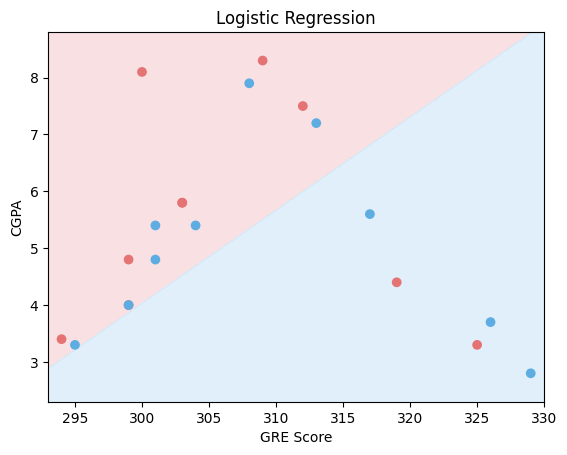

In [32]:
logistic_regression = LogisticRegression()
logistic_regression.fit(X,y)

# Creating a meshgrid of GRE score and CGPA
X1_min = X[:, 0].min()
X1_max = X[:, 0].max()

X2_min = X[:, 1].min()
X2_max = X[:, 1].max()

X1_mesh, X2_mesh = np.meshgrid(np.arange(X1_min - 1, X1_max +1, 0.01),
                               np.arange(X2_min - 1, X2_max + 1, 0.01))

# Classifying each point in meshgrid
input_mesh = np.array([X1_mesh.ravel(), X2_mesh.ravel()]).T # all points in meshgrid as input
label_mesh = logistic_regression.predict(input_mesh) # labels for all points in meshgrid

# Plotting the decision boundary for entire mesh
from matplotlib.colors import ListedColormap
plt.contourf(X1_mesh, X2_mesh, label_mesh.reshape(X1_mesh.shape),  alpha = 0.75, cmap = ListedColormap(('#F8D7DA', '#D6EAF8')))


# Plotting the data points
plt.scatter(X[:,0], X[:,1], c=y, cmap = ListedColormap(('#E57373', '#5DADE2')))
plt.xlim(X1_min - 1, X1_max + 1)
plt.ylim(X2_min - 0.5, X2_max + 0.5)

# Titles and labels
plt.title('Logistic Regression')
plt.xlabel('GRE Score')
plt.ylabel('CGPA')
plt.show()


The visualization illustrates how the Logistic Regression model partitions the feature space into two decision regions. The decision boundary represents the point at which the predicted probability is equal to the classification threshold, separating the two classes.